## Import libraries

In [35]:
import pandas as pd #reading
import numpy as np #transformation
import matplotlib.pyplot as plt #visual
import seaborn as sns #visual
import plotly.express as px #3d/gif visuals
from wordcloud import WordCloud

## Data collection

In [36]:
df = pd.read_csv('Viral_Social_Media_Trends.csv')


## Data exploration

In [37]:
# Apply a purple-themed Seaborn style
sns.set_style("whitegrid")# White background with gridlines sns.set_palette("Purples")
sns.set_palette("Purples")  #- Purple color theme sns. set_context ("notebook", font_scale=1.2)
sns. set_context ("notebook", font_scale=1.2)  # - Set the font scale to 1.2

In [40]:
df.head()

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [41]:
df.shape

(5000, 10)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Post_ID           5000 non-null   object
 1   Platform          5000 non-null   object
 2   Hashtag           5000 non-null   object
 3   Content_Type      5000 non-null   object
 4   Region            5000 non-null   object
 5   Views             5000 non-null   int64 
 6   Likes             5000 non-null   int64 
 7   Shares            5000 non-null   int64 
 8   Comments          5000 non-null   int64 
 9   Engagement_Level  5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB


In [43]:
df.describe(include='all')

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
count,5000,5000,5000,5000,5000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000
unique,5000,4,10,6,8,NaN,NaN,NaN,NaN,3
top,Post_1,YouTube,#Fitness,Live Stream,USA,NaN,NaN,NaN,NaN,Low
freq,1,1324,536,855,677,NaN,NaN,NaN,NaN,1729
mean,NaN,NaN,NaN,NaN,NaN,2.494066e+06,251475.029800,50519.562000,24888.393800,NaN
std,NaN,NaN,NaN,NaN,NaN,1.459490e+06,144349.583384,29066.362671,14284.504319,NaN
min,NaN,NaN,NaN,NaN,NaN,1.266000e+03,490.000000,52.000000,18.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.186207e+06,126892.250000,25029.000000,12305.250000,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.497373e+06,249443.000000,50839.500000,25004.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,3.759781e+06,373970.750000,75774.250000,37072.750000,NaN


In [44]:
# Prints all column names in the dataset
print(df.columns)

Index(['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views',
       'Likes', 'Shares', 'Comments', 'Engagement_Level'],
      dtype='object')


In [45]:
print(df.iloc())

In [46]:
#comparison operators and maskking
mask = df['Likes'] > 1000
print(mask)

0       True
1       True
2       True
3       True
4       True
        ... 
4995    True
4996    True
4997    True
4998    True
4999    True
Name: Likes, Length: 5000, dtype: bool


In [48]:
# Checking for missing values
print(df.isnull().sum())

# Checking the distribution of the target variable
target_column = 'Likes'  
print(df[target_column].value_counts())


Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64
Likes
399795    2
160629    2
274462    2
90120     2
480028    2
         ..
56857     1
419822    1
160349    1
17460     1
72744     1
Name: count, Length: 4972, dtype: int64


In [49]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna({'Hashtag': 'Unknown', 'Region': 'Unknown'}, inplace=True)

In [50]:
num = ['Views', 'Likes', 'Shares', 'Comments']

In [51]:
ds = {
    'Mean': df[num].mean(),
    'Median': df[num].median(),
    'Mode': df[num].mode(),
    'Variance': df[num].var(),
    'Standard Deviation': df[num].std(),
    'Skewness': df[num].skew(),
    'Kurtosis': df[num].kurt()
}

ds

{'Mean': Views       2.494066e+06
 Likes       2.514750e+05
 Shares      5.051956e+04
 Comments    2.488839e+04
 dtype: float64,
 'Median': Views       2497373.0
 Likes        249443.0
 Shares        50839.5
 Comments      25004.0
 dtype: float64,
 'Mode':         Views   Likes   Shares  Comments
 0   1358058.0   34145  34856.0    1905.0
 1   1655182.0   36572  96016.0   13106.0
 2   2737221.0   43890      NaN   13429.0
 3   3283134.0   50849      NaN   20155.0
 4         NaN   51266      NaN   25488.0
 5         NaN   87132      NaN   28304.0
 6         NaN   90120      NaN   33207.0
 7         NaN  123912      NaN   43357.0
 8         NaN  155459      NaN       NaN
 9         NaN  160629      NaN       NaN
 10        NaN  187743      NaN       NaN
 11        NaN  210072      NaN       NaN
 12        NaN  210894      NaN       NaN
 13        NaN  247328      NaN       NaN
 14        NaN  260597      NaN       NaN
 15        NaN  267582      NaN       NaN
 16        NaN  274462      Na

In [ ]:
## Data preprocessing

In [11]:
# getting duplicated values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool


## Data analysis

### Univariate analysis

<Figure size 1500x400 with 0 Axes>

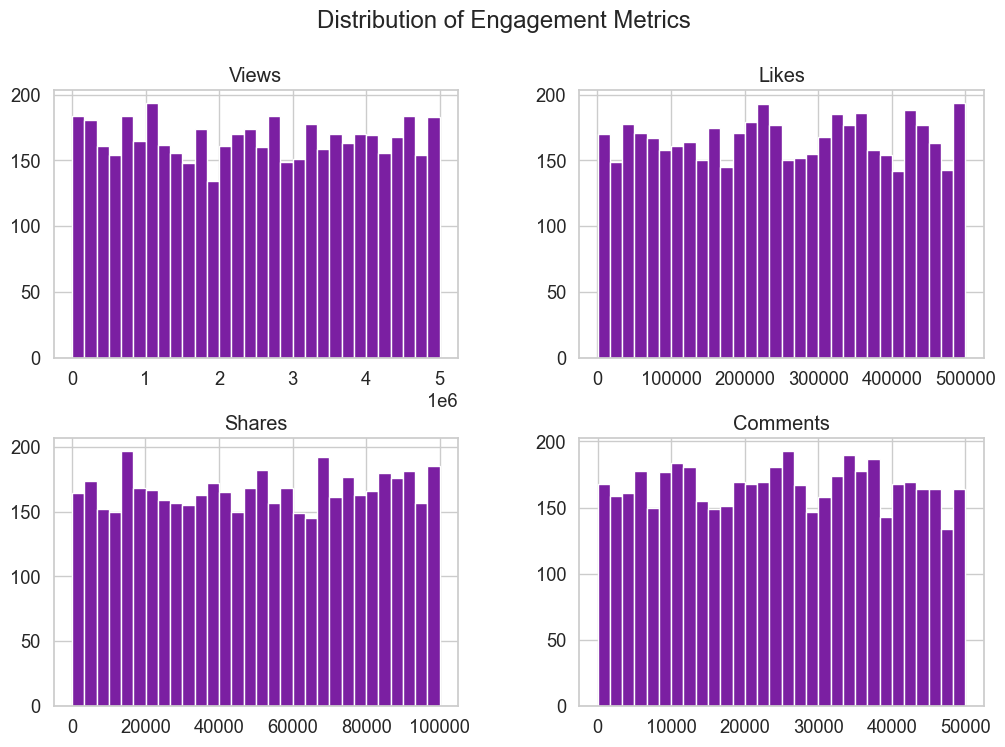

In [52]:
plt. figure(figsize=(15, 4))
df[[ 'Views',
'Likes',
'Shares',
'Comments' ]].hist(bins=30, figsize=(12, 8), color="#7B1FA2")
plt.suptitle( 'Distribution of Engagement Metrics') 
plt.show()

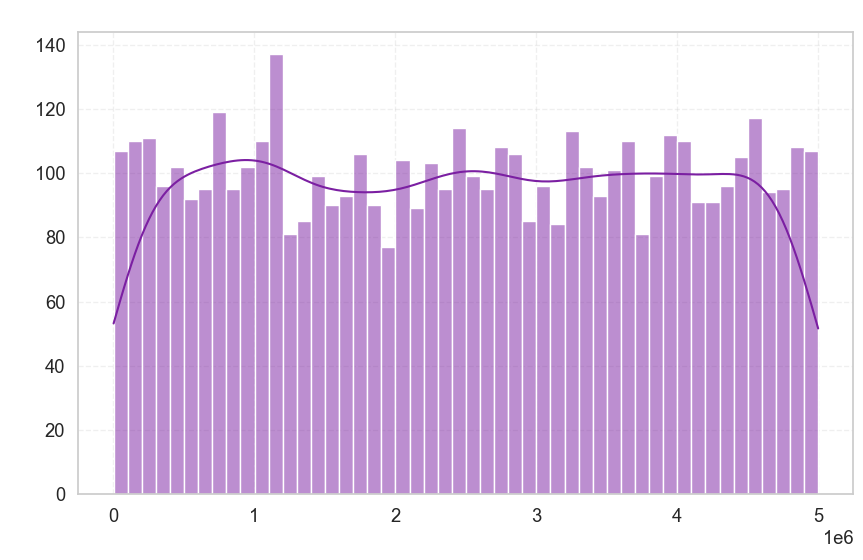

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Views"], bins=50, kde=True, color="#7B1FA2")
# Dark Purple
plt.title("Distribution of Views", fontsize=14, color="white") 
plt.xlabel("Views", color="white")
plt.ylabel("Frequency", color="white")
plt.grid(True, linestyle="--", alpha=0.3) 
plt. show()

## Platform based analysis

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_12416/3811549492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Platform", y="Likes", data=df, palette="Purples")


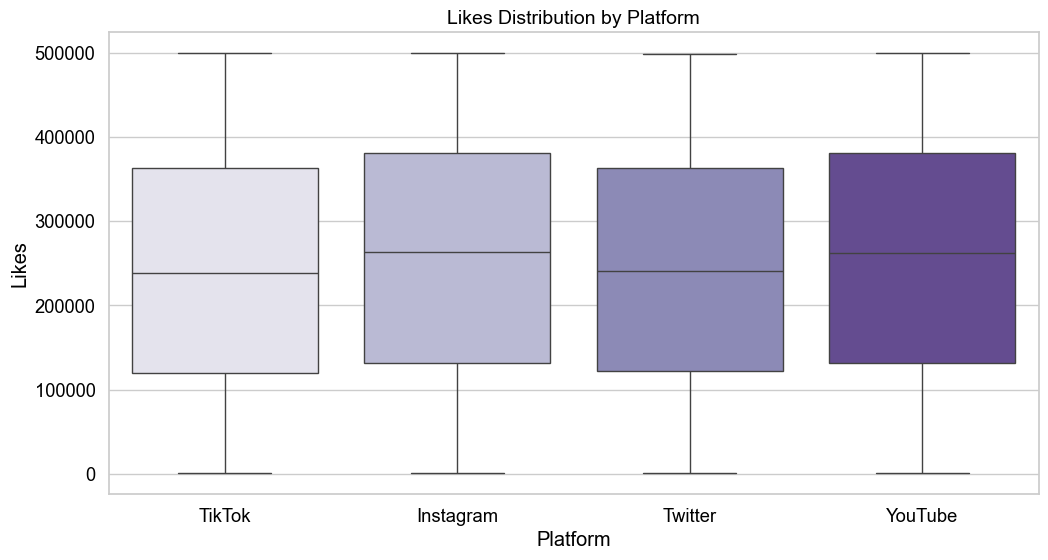

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Platform", y="Likes", data=df, palette="Purples")
plt.title("Likes Distribution by Platform", fontsize=14, color="black") 
plt.xlabel("Platform", color="black")
plt.ylabel("Likes", color="black")
plt.xticks(color="black")
plt.yticks(color="black")
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_12416/2156789281.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




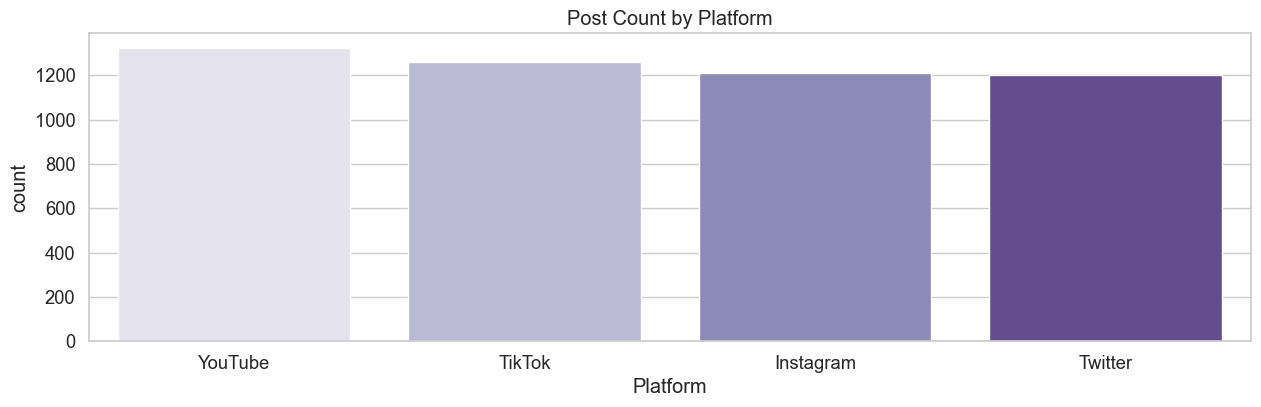

In [26]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x='Platform', palette='Purples', order=df['Platform'].value_counts().index)
plt. title('Post Count by Platform')
plt. show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_12416/836030943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='Purples', order=df['Region' ].value_counts().index)


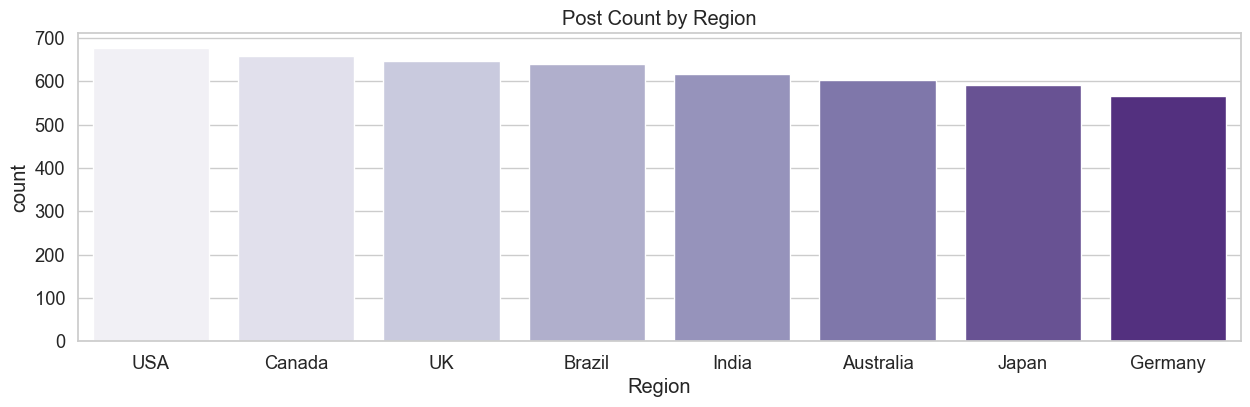

In [17]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x='Region', palette='Purples', order=df['Region' ].value_counts().index)
plt.title('Post Count by Region')
plt.show()

## Content type distribution

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_12416/121961352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Content_Type', y='Views', palette='Purples')


Text(0.5, 1.0, 'Number of Views by Content Type')

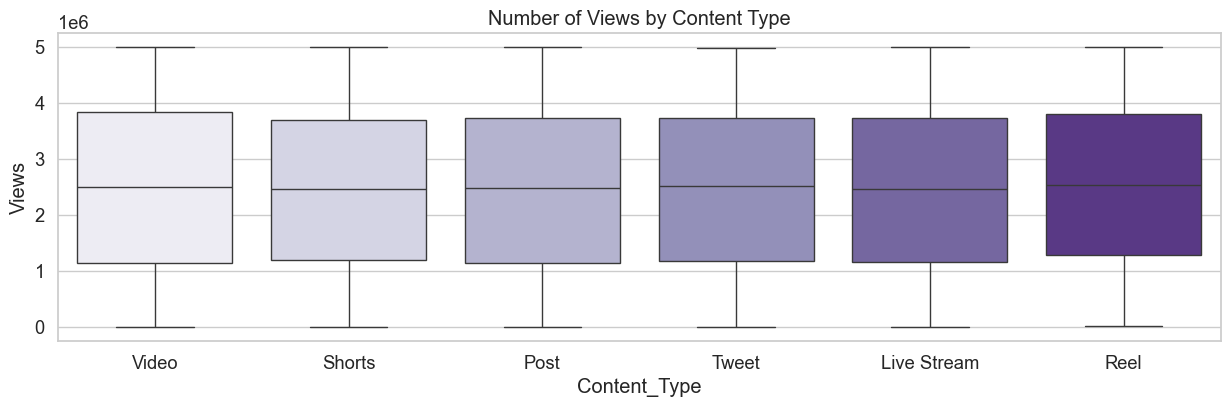

In [18]:
plt.figure(figsize=(15, 4))
sns.boxplot(data=df, x='Content_Type', y='Views', palette='Purples')
plt.title('Number of Views by Content Type')

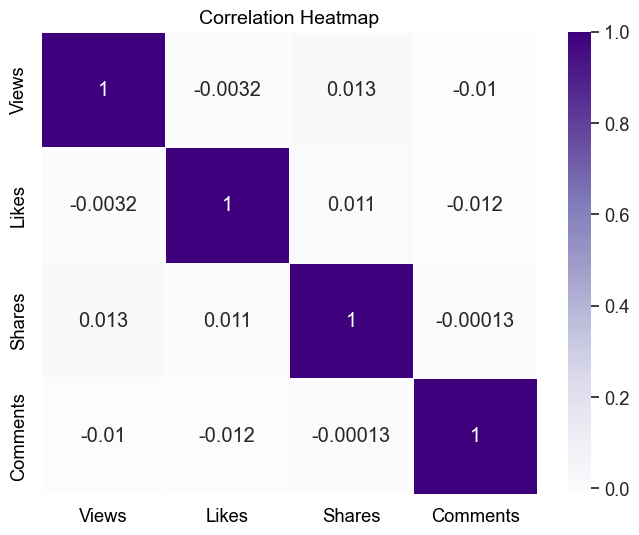

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Views', 'Likes','Shares','Comments' ]].corr(), annot=True, cmap="Purples", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, color="black") 
plt.xticks(color="black")
plt.yticks(color="black")
plt.show()

In [21]:
fig = px. scatter(df, x='Views', y='Likes', color='Platform', hover_data=['Hashtag', 'Region'],
                  title='Views vs Likes Across Platform')

fig. show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Engagement_Level", data=df, palette="Purples") 
plt.title("Engagement Level Distribution", fontsize=14, color="black") 
plt.xlabel ("Engagement Level", color="black") 
plt.ylabel("Count", color="black")
plt.xticks(color="black'")
plt.yticks(color="black")
plt.show()